# Notebook 06 — LSTM Backbone

**Purpose:** Define, pre-train, and save the LSTM backbone.

**Architecture:**
- Input: list of `n_streams` arrays, each `(batch, T=250, 3)`
- Per-stream: 2-layer Bidirectional LSTM → final hidden state → `(batch, 2*hidden_size)`
- All stream hidden states concatenated → linear projection → `EMBEDDING_DIM=128`
- Classification head for pre-training, removed for FSL use

**Why bidirectional:**  
Bidirectional LSTMs see the full temporal context in both directions,  
which is well-suited for fixed-length activity windows where  
the beginning and end of a motion are both informative.

**Interface is identical to CNN backbone:**  
`backbone.get_embedding(stream_list)` returns `(batch, 128)`  
FSL methods require no changes to work with this backbone.

---
**Run notebook 00 first. Run at least notebook 01 (WISDM preprocessing) first.**  
Phase 3: train on WISDM alongside CNN and Transformer for backbone comparison.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

# ─── Which dataset to train on ────────────────────────────────────────────────
# Phase 3: 'wisdm'  |  Phase 4: 'cogage_atomic', 'cogage_composite', 'humcare'
DATASET_NAME = 'wisdm'

print(f'\n✅ Setup complete')
print(f'   Backbone : LSTM (Bidirectional, 2-layer)')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   Device   : {DEVICE}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Load Dataset

Identical to notebook 05 — reuses `MultiStreamDataset` and `multistream_collate`  
from notebook 00 via `%run`.

In [ ]:
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']

n_streams  = len(stream_names)
n_classes  = cfg['n_classes']
N, T, C    = streams[stream_names[0]].shape

# Force both sides to strings for bulletproof matching
sub_ids_str = subject_ids.astype(str)
train_split = [str(s) for s in split_info['train']]
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

# Build subject masks
train_mask = get_split_mask(sub_ids_str, train_split)
val_mask   = get_split_mask(sub_ids_str, val_split)
test_mask  = get_split_mask(sub_ids_str, test_split)

print(f'── Dataset summary ──')
print(f'   Dataset    : {DATASET_NAME}')
print(f'   N windows  : {N:,}')
print(f'   T timesteps: {T}')
print(f'   Streams    : {n_streams}  →  {stream_names}')
print(f'   Classes    : {n_classes}')
print(f'   Train      : {train_mask.sum():,} | Val: {val_mask.sum():,} | Test: {test_mask.sum():,}')

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset summary ──
   Dataset    : wisdm
   N windows  : 63,513
   T timesteps: 250
   Streams    : 4  →  ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']
   Classes    : 18
   Train      : 47,037 | Val: 7,596 | Test: 8,880


## Cell 3 — LSTM Backbone Architecture

```
For each sensor stream:
  Input  (batch, T, 3)          # time-first — perfect for LSTM
    → BiLSTM(3→hidden, 2 layers)
    → output: (batch, T, 2*hidden)   # bidirectional doubles hidden size
    → take last timestep: (batch, 2*hidden)
    → Dropout
    → stream_feature: (batch, D_stream = 2*hidden)

Fusion:
  Concatenate all stream outputs → (batch, n_streams × D_stream)
  Linear → ReLU → (batch, EMBEDDING_DIM=128)

Classification head (pre-training only):
  Linear(128 → n_classes)
```

**Justification - Dropout Rates:** A standard 0.3 dropout was applied to the recurrent layers to prevent co-adaptation of hidden states over time.

In [ ]:
class StreamLSTMEncoder(nn.Module):
    """
    Bidirectional 2-layer LSTM encoder for a single sensor stream.

    Input : (batch, T, 3)         — time-first, 3 axes
    Output: (batch, 2*hidden_size) — bidirectional final hidden state
    """

    def __init__(
        self,
        input_size  : int   = 3,
        hidden_size : int   = 64,
        num_layers  : int   = 2,
        dropout     : float = 0.3,
    ):
        super().__init__()

        self.hidden_size  = hidden_size
        self.bidirectional = True
        self.d_stream     = hidden_size * 2   # bidirectional doubles output

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,       # input/output: (batch, T, features)
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        # Dropout applied to final hidden state
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (batch, T, 3) — time-first
        Returns:
            (batch, 2*hidden_size)
        """
        # output : (batch, T, 2*hidden_size)
        # h_n    : (num_layers*2, batch, hidden_size)  — 2 = bidirectional
        output, (h_n, c_n) = self.lstm(x)

        # Take the last timestep output — contains full sequence context
        # for a bidirectional LSTM this is the concatenation of:
        #   forward direction  final hidden  (saw tokens 0..T-1)
        #   backward direction final hidden  (saw tokens T-1..0)
        last_out = output[:, -1, :]   # (batch, 2*hidden_size)

        return self.dropout(last_out)


class LSTMBackbone(nn.Module):
    """
    Multi-stream LSTM backbone.

    Processes each sensor stream independently with a shared StreamLSTMEncoder,
    then fuses stream embeddings into a single joint embedding.

    Interface is identical to CNNBackbone:
        forward(stream_list, return_embedding=False) → logits
        forward(stream_list, return_embedding=True)  → embedding
        get_embedding(stream_list)                   → embedding
    """

    def __init__(
        self,
        n_streams      : int,
        n_classes      : int,
        input_size     : int   = 3,
        hidden_size    : int   = 64,
        num_layers     : int   = 2,
        dropout        : float = 0.3,
        embedding_dim  : int   = EMBEDDING_DIM,
    ):
        super().__init__()

        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        d_stream           = hidden_size * 2   # bidirectional

        # One LSTM encoder per stream
        self.stream_encoders = nn.ModuleList([
            StreamLSTMEncoder(
                input_size  = input_size,
                hidden_size = hidden_size,
                num_layers  = num_layers,
                dropout     = dropout,
            )
            for _ in range(n_streams)
        ])

        # Fusion: concatenated stream features → joint embedding
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
        )

        # Classification head — pre-training only
        self.classifier = nn.Linear(embedding_dim, n_classes)

    def forward(
        self,
        stream_list      : List[torch.Tensor],
        return_embedding : bool = False
    ) -> torch.Tensor:
        """
        Args:
            stream_list      : list of n_streams tensors, each (batch, T, 3)
            return_embedding : True → return (batch, 128) embedding
                               False → return (batch, n_classes) logits
        """
        assert len(stream_list) == self.n_streams, (
            f'Expected {self.n_streams} streams, got {len(stream_list)}'
        )

        # Encode each stream independently
        stream_features = [
            encoder(stream)
            for encoder, stream in zip(self.stream_encoders, stream_list)
        ]   # list of n_streams tensors, each (batch, 2*hidden_size)

        # Concatenate and project
        fused     = torch.cat(stream_features, dim=-1)   # (batch, n_streams * 2*hidden)
        embedding = self.fusion(fused)                    # (batch, embedding_dim)

        if return_embedding:
            return embedding

        return self.classifier(embedding)

    def get_embedding(self, stream_list: List[torch.Tensor]) -> torch.Tensor:
        """Convenience method — always returns embedding. Used by FSL methods."""
        return self.forward(stream_list, return_embedding=True)


# ─── Architecture test ────────────────────────────────────────────────────────
print('Testing LSTM backbone architecture...')
_batch  = 8
_model  = LSTMBackbone(n_streams=n_streams, n_classes=n_classes).to(DEVICE)
_dummy  = [torch.randn(_batch, T, C).to(DEVICE) for _ in range(n_streams)]

_emb    = _model(_dummy, return_embedding=True)
_logits = _model(_dummy, return_embedding=False)

print(f'   n_streams    : {n_streams}')
print(f'   Input/stream : (batch={_batch}, T={T}, C={C})')
print(f'   Embedding    : {_emb.shape}    (expected ({_batch}, {EMBEDDING_DIM}))')
print(f'   Logits       : {_logits.shape}  (expected ({_batch}, {n_classes}))')

n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'   Trainable params: {n_params:,}')

assert _emb.shape    == (_batch, EMBEDDING_DIM)
assert _logits.shape == (_batch, n_classes)
del _model, _dummy, _emb, _logits
print('\n✅ Architecture test passed')

Testing LSTM backbone architecture...
   n_streams    : 4
   Input/stream : (batch=8, T=250, C=3)
   Embedding    : torch.Size([8, 128])    (expected (8, 128))
   Logits       : torch.Size([8, 18])  (expected (8, 18))
   Trainable params: 606,610

✅ Architecture test passed


## Cell 4 — DataLoaders

Identical to notebook 05

In [ ]:
# ─── Augmentation utilities ───────────────────────────────────────────────────
def augment_stream(x: torch.Tensor) -> torch.Tensor:
    """Apply sensor-agnostic augmentation to a single stream."""
    if torch.rand(1) < 0.5:
        noise = 0.01 * torch.randn_like(x)
        x = x + noise
    if torch.rand(1) < 0.5:
        scale = torch.randn(1).item() * 0.1 + 1.0
        x = x * scale
    if torch.rand(1) < 0.3:
        T = x.shape[0]
        mask_len = int(0.1 * T)
        start = torch.randint(0, T - mask_len, (1,)).item()
        x[start:start+mask_len] = 0
    if torch.rand(1) < 0.5:
        theta = torch.randn(1).item() * 0.2
        cos, sin = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
        R = torch.tensor([
            [cos, -sin, 0],
            [sin,  cos, 0],
            [0,    0,   1]
        ], dtype=torch.float32)
        x = x @ R
    return x

# ─── Dataset ──────────────────────────────────────────────────────────────────
class MultiStreamDataset(torch.utils.data.Dataset):
    def __init__(
        self, streams: Dict[str, np.ndarray], y: np.ndarray,
        stream_names: List[str], mask: np.ndarray, augment: bool = False,
    ):
        self.stream_arrays = [streams[name][mask].astype(np.float32) for name in stream_names]
        self.labels       = y[mask].astype(np.int64)
        self.n_samples    = mask.sum()
        self.stream_names = stream_names
        self.augment      = augment

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int):
        stream_list = []
        for arr in self.stream_arrays:
            x = torch.tensor(arr[idx], dtype=torch.float32)
            if self.augment:
                x = augment_stream(x)
            stream_list.append(x)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return stream_list, label

def multistream_collate(batch):
    stream_lists, labels = zip(*batch)
    n_streams = len(stream_lists[0])
    batched_streams = [
        torch.stack([s[i] for s in stream_lists], dim=0)
        for i in range(n_streams)
    ]
    batched_labels = torch.stack(labels, dim=0)
    return batched_streams, batched_labels

# ─── Build datasets and loaders ───────────────────────────────────────────────
train_dataset = MultiStreamDataset(streams, y, stream_names, train_mask, augment=True)
val_dataset   = MultiStreamDataset(streams, y, stream_names, val_mask, augment=False)
test_dataset  = MultiStreamDataset(streams, y, stream_names, test_mask, augment=False)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=multistream_collate, num_workers=0,
    pin_memory=True if DEVICE.type == 'cuda' else False,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=multistream_collate, num_workers=0,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=multistream_collate, num_workers=0,
)

print('✅ DataLoaders ready (with augmentation)')
print(f'   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

✅ DataLoaders ready (with augmentation)
   Train: 1470 batches | Val: 238 | Test: 278


## Cell 5 — Training Utilities

Same `train_one_epoch` and `evaluate` functions as notebook 05.  
Defined here so this notebook is self-contained.

In [ ]:
def train_one_epoch(
    model     : nn.Module,
    loader    : torch.utils.data.DataLoader,
    optimizer : torch.optim.Optimizer,
    criterion : nn.Module,
) -> Tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0

    for stream_list, labels in loader:
        stream_list = [s.to(DEVICE) for s in stream_list]
        labels      = labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(stream_list, return_embedding=False)
        loss   = criterion(logits, labels)
        loss.backward()
        # Gradient clipping — especially important for LSTMs to prevent
        # exploding gradients over long sequences
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model     : nn.Module,
    loader    : torch.utils.data.DataLoader,
    criterion : nn.Module,
) -> Tuple[float, float, float]:
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for stream_list, labels in loader:
        stream_list = [s.to(DEVICE) for s in stream_list]
        labels      = labels.to(DEVICE)
        logits      = model(stream_list, return_embedding=False)
        loss        = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.append(logits.argmax(-1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return (
        total_loss / len(all_labels),
        compute_accuracy(all_labels, all_preds),
        compute_macro_f1(all_labels, all_preds),
    )


print('✅ Training utilities defined')
print('   Note: gradient clipping (max_norm=1.0) applied — standard for LSTMs')

✅ Training utilities defined
   Note: gradient clipping (max_norm=1.0) applied — standard for LSTMs


## Cell 6 — Initialise Model, Optimizer, Scheduler

**Justification - Optimization Dynamics:** Base training utilized a Cosine Annealing scheduler (decaying to 1e-5) allowing the models to explore the loss landscape before smoothly settling into local minima. L2 Regularization (weight_decay=1e-4) was tailored to the capacity of the LSTM model, as its architectural inductive biases naturally constrain the hypothesis space.

In [ ]:
seed_everything(MASTER_SEED)

model = LSTMBackbone(
    n_streams     = n_streams,
    n_classes     = n_classes,
    input_size    = C,
    hidden_size   = 64,
    num_layers    = 2,
    dropout       = 0.3,
    embedding_dim = EMBEDDING_DIM,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = BACKBONE_EPOCHS,
    eta_min = 1e-5,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ LSTM model initialised')
print(f'   Trainable params : {n_params:,}')
print(f'   Hidden size      : 64 (bidirectional → 128 per stream)')
print(f'   Layers           : 2')
print(f'   Dropout          : 0.3')
print(f'   Optimizer        : Adam (lr={LEARNING_RATE}, wd=1e-4)')
print(f'   Scheduler        : CosineAnnealingLR')
print(f'   Gradient clip    : max_norm=1.0')

✅ LSTM model initialised
   Trainable params : 606,610
   Hidden size      : 64 (bidirectional → 128 per stream)
   Layers           : 2
   Dropout          : 0.3
   Optimizer        : Adam (lr=0.0003, wd=1e-4)
   Scheduler        : CosineAnnealingLR
   Gradient clip    : max_norm=1.0


## Cell 7 — Training Loop

In [ ]:
ckpt_dir  = os.path.join(CHECKPOINT_BASE, DATASET_NAME, 'lstm')
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, 'best_backbone.pt')

PATIENCE       = 10
best_val_acc   = 0.0
patience_count = 0

history = {
    'train_loss':[], 'train_acc':[],
    'val_loss':  [], 'val_acc':  [], 'val_f1':[],
    'lr':        [],
}

print(f'Training LSTM backbone on {DATASET_NAME}...')
print(f'Checkpoint : {ckpt_path}')
print(f'{"─"*65}')
print(f'{"Epoch":>5} {"TrainLoss":>10} {"TrainAcc":>10} {"ValLoss":>10} {"ValAcc":>8} {"ValF1":>8} {"LR":>10}')
print(f'{"─"*65}')

for epoch in range(1, BACKBONE_EPOCHS + 1):
    train_loss, train_acc          = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc,   val_f1  = evaluate(model, val_loader, criterion)
    current_lr  = scheduler.get_last_lr()[0]
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc   = val_acc
        patience_count = 0
        save_checkpoint(
            model, ckpt_path,
            extra={
                'epoch'       : epoch,
                'val_acc'     : val_acc,
                'val_f1'      : val_f1,
                'dataset'     : DATASET_NAME,
                'backbone'    : 'lstm',
                'n_streams'   : n_streams,
                'n_classes'   : n_classes,
                'stream_names': stream_names,
            }
        )
    else:
        patience_count += 1

    marker = ' ✅' if improved else ''
    print(
        f'{epoch:>5} '
        f'{train_loss:>10.4f} '
        f'{train_acc*100:>9.2f}% '
        f'{val_loss:>10.4f} '
        f'{val_acc*100:>7.2f}% '
        f'{val_f1:>8.4f} '
        f'{current_lr:>10.6f}'
        f'{marker}'
    )

    if patience_count >= PATIENCE:
        print(f'\n   Early stopping at epoch {epoch}')
        break

print(f'\n{"─"*65}')
print(f'✅ Training complete — best val acc: {best_val_acc*100:.2f}%')

Training LSTM backbone on wisdm...
Checkpoint : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/lstm/best_backbone.pt
─────────────────────────────────────────────────────────────────
Epoch  TrainLoss   TrainAcc    ValLoss   ValAcc    ValF1         LR
─────────────────────────────────────────────────────────────────
    1     2.1856     32.00%     1.9261   44.60%   0.4141   0.000300 ✅
    2     1.8700     44.60%     1.8463   47.53%   0.4385   0.000300 ✅
    3     1.7621     49.43%     1.8250   49.39%   0.4587   0.000299 ✅
    4     1.6842     52.59%     1.7203   51.36%   0.4871   0.000297 ✅
    5     1.6170     56.08%     1.7211   52.57%   0.5182   0.000295 ✅
    6     1.5546     59.22%     1.6592   56.10%   0.5441   0.000293 ✅
    7     1.4930     62.31%     1.6127   57.89%   0.5665   0.000290 ✅
    8     1.4457     64.65%     1.5896   61.12%   0.5983   0.000286 ✅
    9     1.3956     66.82%     1.5424   60.85%   0.6043   0.000282
   10     1.3540     68.54%     1.5567   60.90%   0.6

## Cell 8 — Training Curves

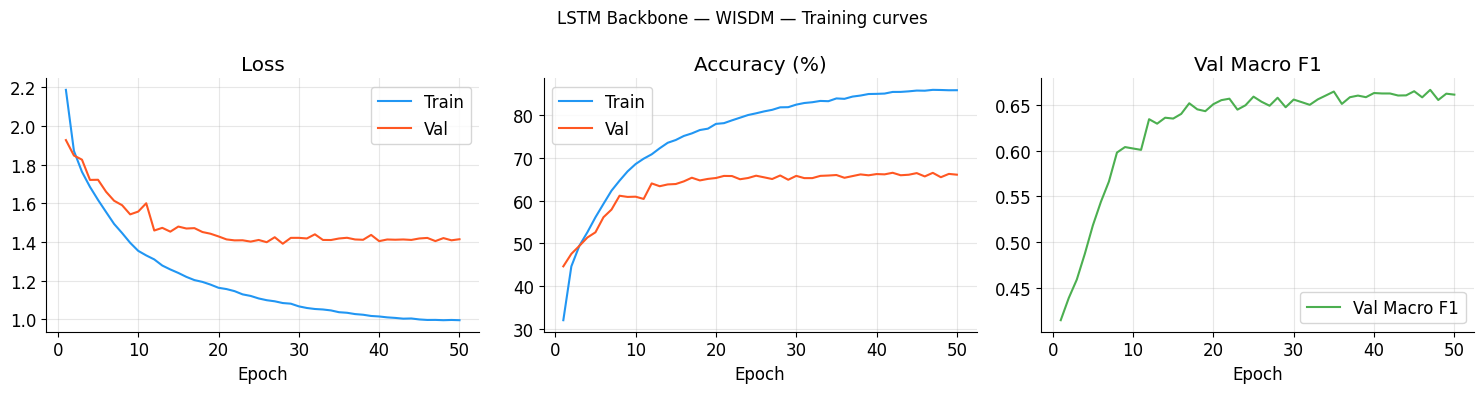

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/lstm/training_curves.png


In [ ]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#FF5722')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#2196F3')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#FF5722')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(ep, history['val_f1'], color='#4CAF50', label='Val Macro F1')
axes[2].set_title('Val Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

fig.suptitle(f'LSTM Backbone — {DATASET_NAME.upper()} — Training curves', fontsize=12)
plt.tight_layout()
plot_path = os.path.join(ckpt_dir, 'training_curves.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

## Cell 9 — Test Set Evaluation

In [ ]:
best_model = LSTMBackbone(
    n_streams     = n_streams,
    n_classes     = n_classes,
    input_size    = C,
    hidden_size   = 64,
    num_layers    = 2,
    dropout       = 0.3,
    embedding_dim = EMBEDDING_DIM,
).to(DEVICE)

meta = load_checkpoint(best_model, ckpt_path)
print(f'Loaded checkpoint from epoch {meta.get("epoch", "?")}')

test_loss, test_acc, test_f1 = evaluate(best_model, test_loader, criterion)

print(f'\n── Test set results ──')
print(f'   Test accuracy  : {test_acc*100:.2f}%')
print(f'   Test macro F1  : {test_f1:.4f}')
print(f'   Test loss      : {test_loss:.4f}')

result = {
    'dataset'   : DATASET_NAME,
    'backbone'  : 'lstm',
    'method'    : 'pretrain_classifier',
    'k_shot'    : 0,
    'seed'      : MASTER_SEED,
    'acc_before': test_acc,
    'acc_after' : test_acc,
    'gain'      : 0.0,
    'macro_f1'  : test_f1,
    'best_epoch': meta.get('epoch', -1),
}
config_key = make_config_key(DATASET_NAME, 'lstm', 'pretrain', 0, MASTER_SEED)
mark_completed(config_key, result)
print(f'\n✅ Result saved to registry')

Loaded checkpoint from epoch 42

── Test set results ──
   Test accuracy  : 64.92%
   Test macro F1  : 0.6402
   Test loss      : 1.5102

✅ Result saved to registry


## Cell 10 — Backbone Comparison vs CNN

If notebook 05 has already been run, compare LSTM vs CNN test accuracy  
on the same dataset side by side.

In [ ]:
registry = load_registry()

print(f'── Backbone comparison on {DATASET_NAME} (generalization, no adaptation) ──')
print(f'{"Backbone":<15} {"Test Acc":>10} {"Macro F1":>10} {"Best Epoch":>12}')
print('─' * 50)

for backbone_name in ['cnn', 'lstm', 'transformer']:
    key = make_config_key(DATASET_NAME, backbone_name, 'pretrain', 0, MASTER_SEED)
    if key in registry:
        r = registry[key]
        print(
            f'{backbone_name:<15} '
            f'{r.get("acc_after", 0)*100:>9.2f}% '
            f'{r.get("macro_f1", 0):>10.4f} '
            f'{r.get("best_epoch", "?"):>12}'
        )
    else:
        print(f'{backbone_name:<15} {"not run yet":>10}')

print()
print('Note: full backbone comparison (Phase 3) runs all 3 on same dataset.')
print('Transformer results will appear after notebook 07 is run.')

── Backbone comparison on wisdm (generalization, no adaptation) ──
Backbone          Test Acc   Macro F1   Best Epoch
──────────────────────────────────────────────────
cnn                 69.11%     0.6766           19
lstm                64.92%     0.6402           42
transformer     not run yet

Note: full backbone comparison (Phase 3) runs all 3 on same dataset.
Transformer results will appear after notebook 07 is run.


## Cell 11 — Verify FSL Interface

In [ ]:
print('Verifying LSTM backbone FSL interface...\n')

fsl_backbone = LSTMBackbone(
    n_streams     = n_streams,
    n_classes     = n_classes,
    input_size    = C,
    hidden_size   = 64,
    num_layers    = 2,
    dropout       = 0.3,
    embedding_dim = EMBEDDING_DIM,
).to(DEVICE)

load_checkpoint(fsl_backbone, ckpt_path)
fsl_backbone.eval()

n_way, k_shot  = cfg['n_way'], 5
support_batch  = n_way * k_shot
dummy_support  = [torch.randn(support_batch, T, C).to(DEVICE) for _ in range(n_streams)]

with torch.no_grad():
    emb = fsl_backbone.get_embedding(dummy_support)

assert emb.shape == (support_batch, EMBEDDING_DIM)
norms = emb.norm(dim=-1)

print(f'   Support batch      : {support_batch} ({n_way}-way × {k_shot}-shot)')
print(f'   Embedding shape    : {emb.shape}  ✅')
print(f'   Embedding norms    : mean={norms.mean():.3f}, std={norms.std():.3f}')

del fsl_backbone, dummy_support, emb
print(f'\n✅ LSTM backbone interface verified — ready for FSL notebooks')

Verifying LSTM backbone FSL interface...

   Support batch      : 25 (5-way × 5-shot)
   Embedding shape    : torch.Size([25, 128])  ✅
   Embedding norms    : mean=7.349, std=0.549

✅ LSTM backbone interface verified — ready for FSL notebooks


## Cell 12 — Final Summary

In [ ]:
print('=' * 65)
print('  LSTM BACKBONE TRAINING COMPLETE')
print('=' * 65)
print(f'  Dataset          : {DATASET_NAME}')
print(f'  Architecture     : BiLSTM × 2 layers, hidden=64')
print(f'  Streams          : {n_streams}')
print(f'  Classes          : {n_classes}')
print(f'  Embedding dim    : {EMBEDDING_DIM}')
print(f'  Epochs trained   : {epochs_ran}')
print(f'  Best val acc     : {best_val_acc*100:.2f}%')
print(f'  Test acc         : {test_acc*100:.2f}%  ← generalization baseline')
print(f'  Test macro F1    : {test_f1:.4f}')
print(f'  Checkpoint       : {ckpt_path}')
print('=' * 65)
print()
print('  Next steps:')
print('  Phase 3: → Notebook 07 (Transformer backbone)')
print('  Phase 3: → Run all 4 FSL methods with LSTM backbone')
print('           → Compare CNN vs LSTM vs Transformer on WISDM')
print('=' * 65)

  LSTM BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Architecture     : BiLSTM × 2 layers, hidden=64
  Streams          : 4
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 50
  Best val acc     : 66.50%
  Test acc         : 64.92%  ← generalization baseline
  Test macro F1    : 0.6402
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/lstm/best_backbone.pt

  Next steps:
  Phase 3: → Notebook 07 (Transformer backbone)
  Phase 3: → Run all 4 FSL methods with LSTM backbone
           → Compare CNN vs LSTM vs Transformer on WISDM
